In [7]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [8]:
import matplotlib.pyplot as plt
import warnings

plt.style.use('seaborn')
# plt.style.use('seaborn-colorblind') #alternative
plt.rcParams['figure.figsize'] = [8, 4.5]
plt.rcParams['figure.dpi'] = 300
warnings.simplefilter(action='ignore', category=FutureWarning)

# Chapter 6: Monte Carlo simulations in finance

## Simulating stock price dynamics using Geometric Brownian Motion

1. Import libraries:

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf

2. Define parameters for downloading data:

In [4]:
RISKY_ASSET = 'MSFT'
START_DATE = '2019-01-01'
END_DATE = '2019-07-31'

3. Download data from Yahoo Finance:

In [5]:
df = yf.download(RISKY_ASSET, start=START_DATE, 
                end=END_DATE, adjusted=True)
print(f'Downloaded {df.shape[0]} rows of data.')

df.head()

[*********************100%***********************]  1 of 1 completed
Downloaded 146 rows of data.


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-12-31,101.290001,102.400002,100.440002,101.570000,98.813278,33173800
2019-01-02,99.550003,101.750000,98.940002,101.120003,98.375481,35329300
2019-01-03,100.099998,100.190002,97.199997,97.400002,94.756454,42579100
2019-01-04,99.720001,102.510002,98.930000,101.930000,99.163513,44060600
2019-01-07,101.639999,103.269997,100.980003,102.059998,99.289970,35656100


4. Calculate daily returns:

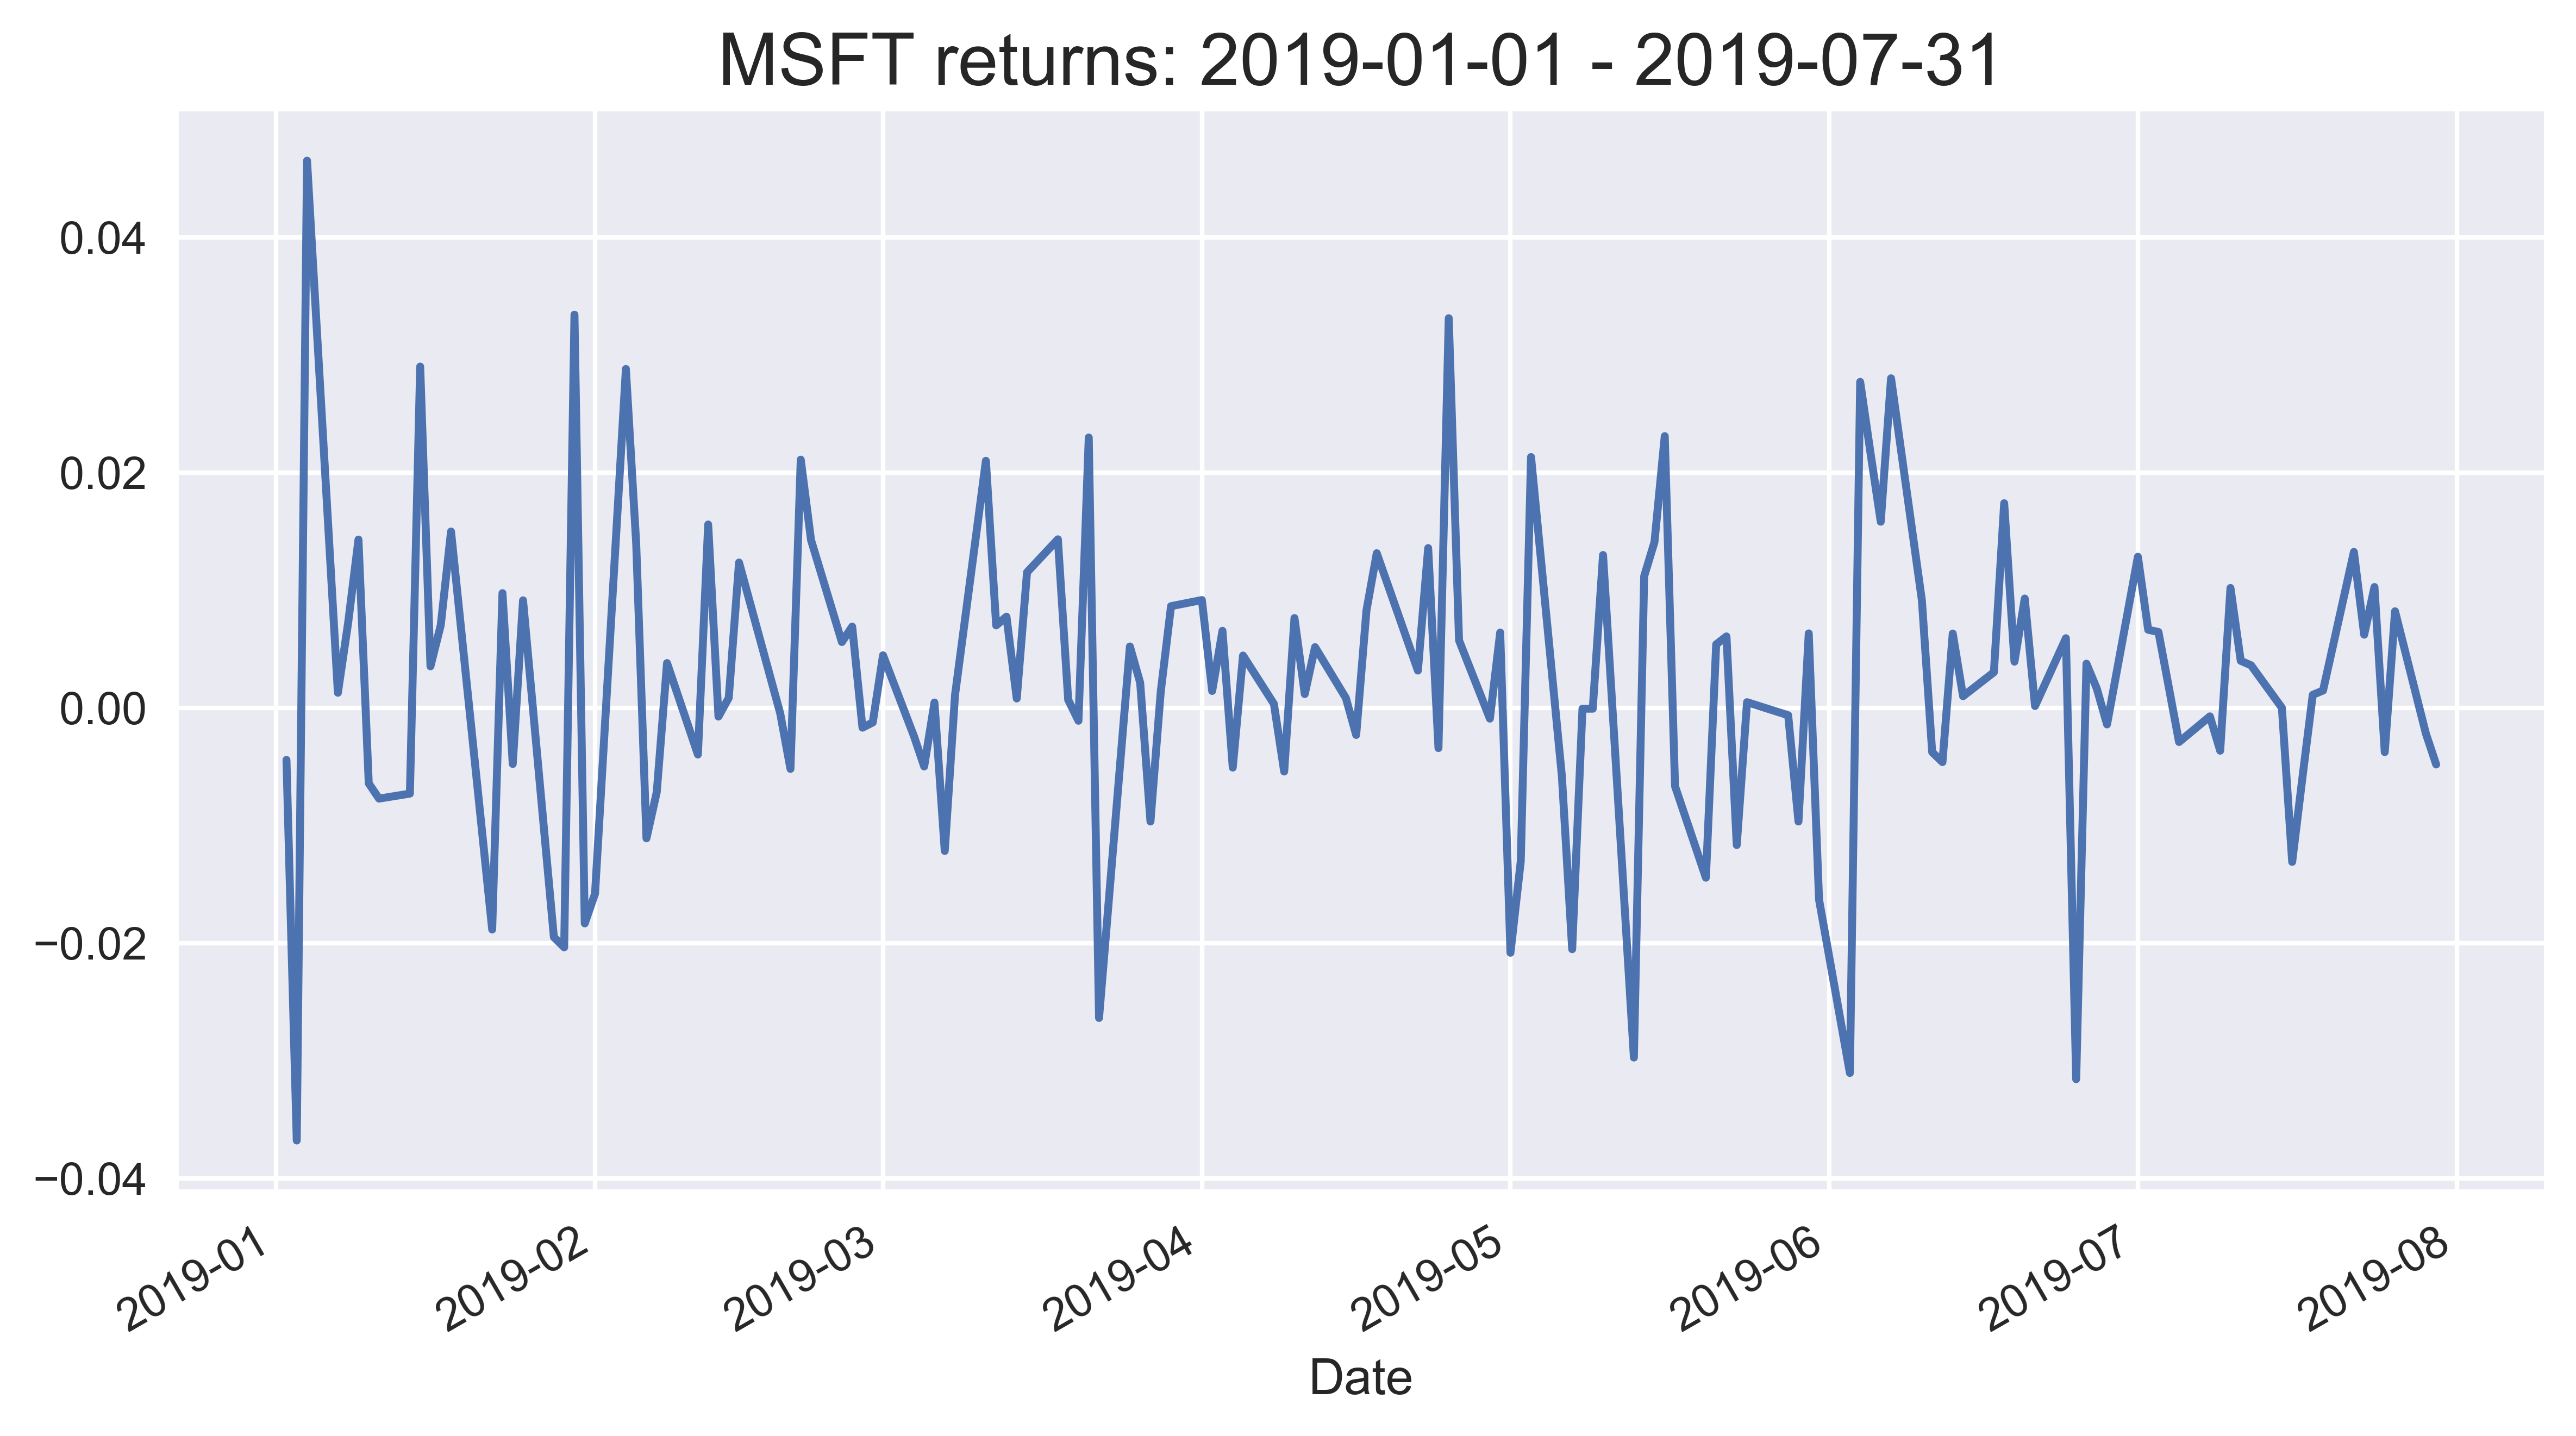

Average return: 0.24%


In [6]:
adj_close = df['Adj Close']
returns = adj_close.pct_change().dropna()

ax = returns.plot()
ax.set_title(f'{RISKY_ASSET} returns: {START_DATE} - {END_DATE}', 
             fontsize=16)

plt.tight_layout()
plt.show()

print(f'Average return: {100 * returns.mean():.2f}%')

5. Split data into the training and test sets:

In [7]:
train = returns['2019-01-01':'2019-06-30']
test = returns['2019-07-01':'2019-07-31']

6. Specify the parameters of the simulation:

In [8]:
T = len(test)
N = len(test)
s_0 = adj_close[train.index[-1]]
N_SIM = 100
mu = train.mean()
sigma = train.std()

7. Define the function used for simulations:

In [9]:
def simulate_gbm(s_0, mu, sigma, n_sims, T, N, 
                random_seed=42):
    '''
    Function used for simulating stock returns using Geometric Brownian Motion.
    
    Parameters
    ------------
    s_0 : float
    Initial stock price
    mu : float
    Drift coefficient
    sigma : float
    Diffusion coefficient
    n_sims : int
    Number of simulations paths
    dt : float
    Time increment, most commonly a day
    T : float
    Length of the forecast horizon, same unit as dt
    N : int
    Number of time increments in the forecast horizon
    random_seed : int
    Random seed for reproducibility
    
    Returns
    -----------
    S_t : np.ndarray
    Matrix (size: n_sims x (T+1)) containing the simulation results. 
    Rows respresent sample paths, while columns point of time.
    '''''
    np.random.seed(random_seed)
    
    dt = T/N
    dW = np.random.normal(scale = np.sqrt(dt), size=(n_sims, N))
    W = np.cumsum(dW, axis=1)
    
    time_step = np.linspace(dt, T, N)
    time_steps = np.broadcast_to(time_step, (n_sims, N))
    
    S_t = s_0 * np.exp((mu - 0.5 * sigma**2) * time_steps 
                      + sigma * W)
    S_t = np.insert(S_t, 0, s_0, axis=1)
    
    return S_t

8. Run the simulations:

In [10]:
gbm_simulations = simulate_gbm(s_0, mu, sigma, N_SIM, T, N)

9. Plot simulation results:

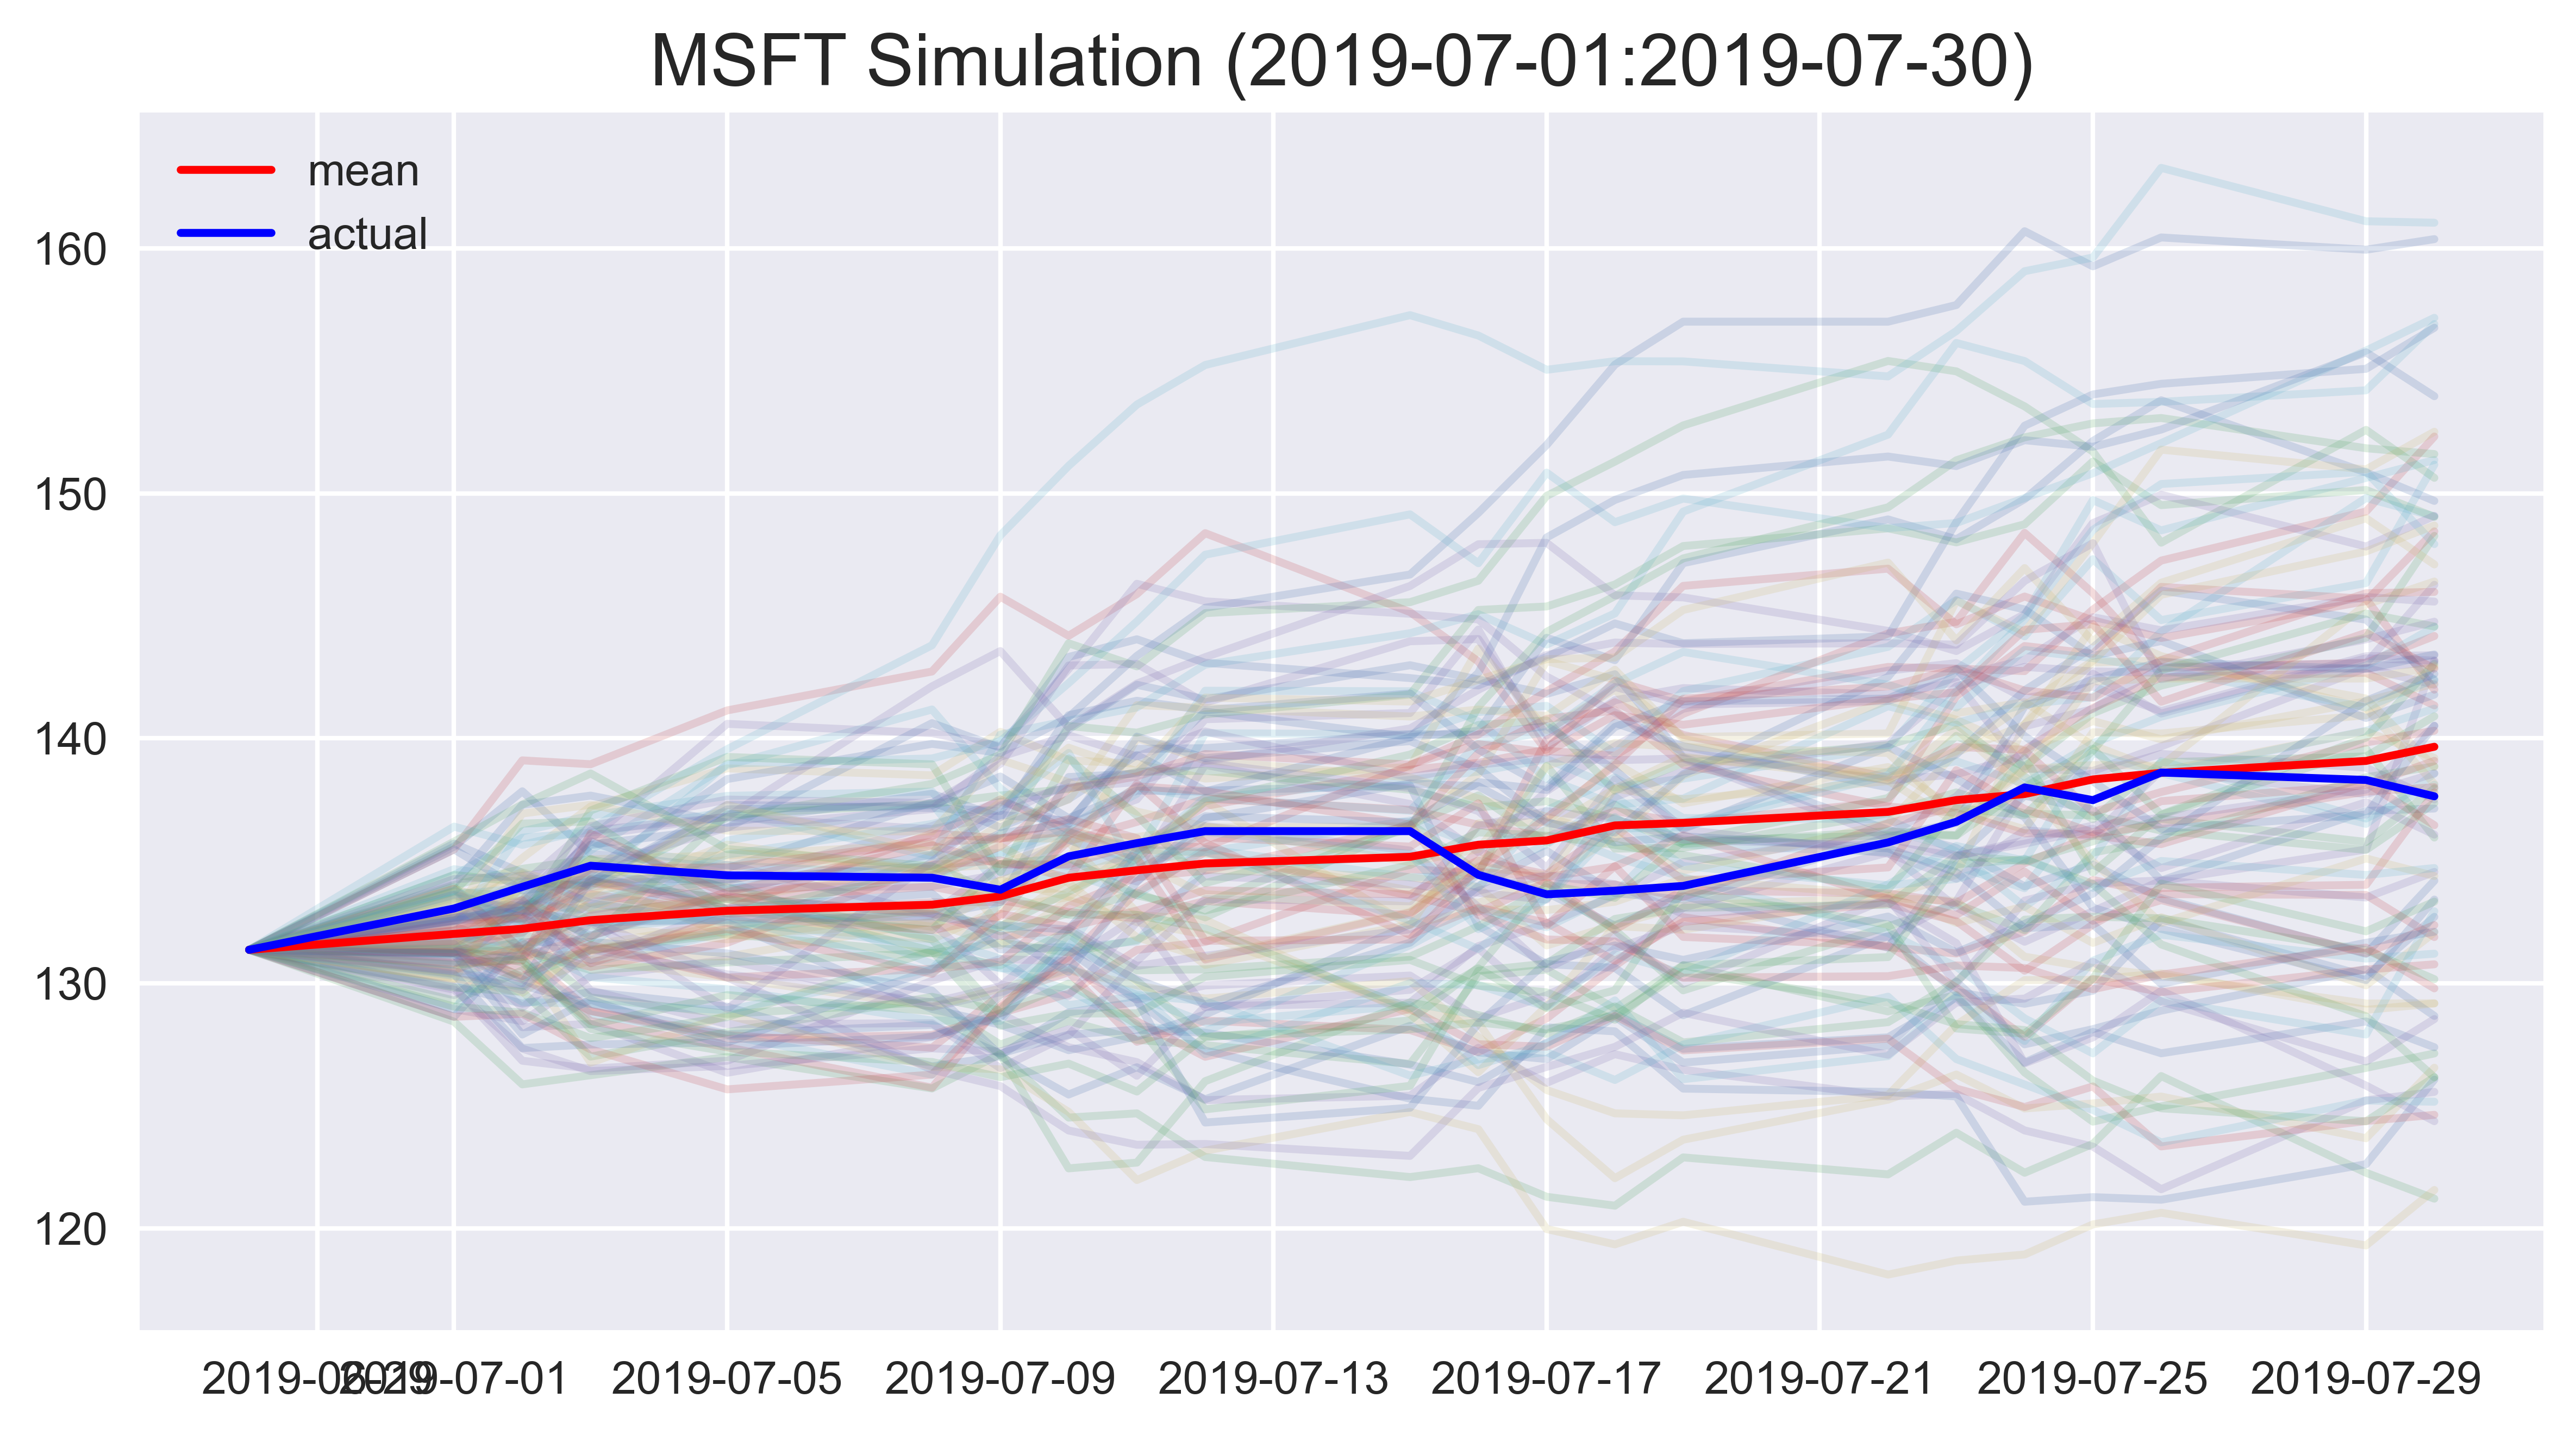

In [11]:
# prepare objects for plotting 
last_train_date = train.index[-1].date()
first_test_date = test.index[0].date()
last_test_date = test.index[-1].date()
plot_title = (f'{RISKY_ASSET} Simulation '
              f'({first_test_date}:{last_test_date})')

selected_indices = adj_close[last_train_date:last_test_date].index
index = [date.date() for date in selected_indices]

gbm_simulations_df = pd.DataFrame(np.transpose(gbm_simulations), 
                                 index=index)

# plotting
ax = gbm_simulations_df.plot(alpha=0.2, legend=False)
line_1, = ax.plot(index, gbm_simulations_df.mean(axis=1), 
                 color='red')
line_2, = ax.plot(index, adj_close[last_train_date:last_test_date], 
                 color='blue')
ax.set_title(plot_title, fontsize=16)
ax.legend((line_1, line_2), ('mean', 'actual'))

plt.tight_layout()
plt.show()

### There's more 

In [13]:
%timeit gbm_simulations = simulate_gbm(s_0, mu, sigma, N_SIM, T, N)

689 µs ± 40.5 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [16]:
def simulate_gbm(s_0, mu, sigma, n_sims, T, N, random_seed=42, antithetic_var=False):
    '''
    Function used for simulating stock returns using Geometric Brownian Motion.
    
    Parameters
    ------------
    s_0 : float
    Initial stock price
    mu : float
    Drift coefficient
    sigma : float
    Diffusion coefficient
    n_sims : int
    Number of simulations paths
    dt : float
    Time increment, most commonly a day
    T : float
    Length of the forecast horizon, same unit as dt
    N : int
    Number of time increments in the forecast horizon
    random_seed : int
    Random seed for reproducibility
    antithetic_var : bool
    Boolean whether to use antithetic variates approach to reduce variance
    
    Returns
    -----------
    S_t : np.ndarray
    Matrix (size: n_sims x (T+1)) containing the simulation results. 
    Rows respresent sample paths, while columns point of time.
    '''''
    
    np.random.seed(random_seed)
        
    # time increment
    dt = T/N
        
    # Brownian
    if antithetic_var:
        dW_ant = np.random.normal(scale = np.sqrt(dt), 
                                     size=(int(n_sims/2), N + 1))
        dW = np.concatenate((dW_ant, -dW_ant), axis=0)
    else: 
        dW = np.random.normal(scale = np.sqrt(dt), 
                                     size=(n_sims, N + 1))
                
    # simulate the evolution of the process
    S_t = s_0 * np.exp(np.cumsum((mu - 0.5 * sigma ** 2) * dt + sigma * dW, 
                                            axis=1)) 
    S_t[:, 0] = s_0
                
    return S_t

In [17]:
%timeit gbm_simulations = simulate_gbm(s_0, mu, sigma, N_SIM, T, N)

349 µs ± 7.84 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [18]:
%timeit gbm_simulations = simulate_gbm(s_0, mu, sigma, N_SIM, T, N, antithetic_var=True)

302 µs ± 21.8 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## Pricing European Options using Simulations 

1. Import the libraries:

In [1]:
import numpy as np
from scipy.stats import norm
from chapter_6_utils import simulate_gbm

2. Define the parameters for the valuation:

In [2]:
S_0 = 100
K = 100
r = 0.05
sigma = 0.50
T = 1 # 1 year
N = 252 # 252 days in a year
dt = T / N # time step
N_SIMS = 100000 # number of simulations
discount_factor = np.exp(-r * T)

3. Define the function using the analytical solution:

In [3]:
def black_scholes_analytical(S_0, K, T, r, sigma, type='call'):
    '''
    Function used for calculating the price of European options using the analytical form of the Black-Scholes model.
    
    Parameters
    ------------
    s_0 : float
    Initial stock price
    K : float
    Strike price
    T : float
    Time to maturity in years
    r : float
    Annualized risk-free rate
    sigma : float
    Standard deviation of the stock returns
    type : str
    Type of the option. Allowable: ['call', 'put']
    
    Returns
    -----------
    option_premium : float
    The premium on the option calculated using the Black-Scholes model
    '''''
    
    d1 = (np.log(S_0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = (np.log(S_0 / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    
    if type == 'call':
        val = (S_0 * norm.cdf(d1, 0, 1) - K * np.exp(-r * T) * norm.cdf(d2, 0, 1))
    elif type == 'put':
        val = (K * np.exp(-r * T) * norm.cdf(-d2, 0, 1) - S_0 * norm.cdf(-d1, 0, 1))
    else:
        raise ValueError('Wrong input for type!')
                
    return val

4. Valuate the call option using the specified parameters:

In [4]:
black_scholes_analytical(S_0=S_0, K=K, T=T, r=r, sigma=sigma, type='call')

21.79260421286685

5. Simulate the stock path using GBM:

In [5]:
gbm_sims = simulate_gbm(s_0=S_0, mu=r, sigma=sigma, 
                       n_sims=N_SIMS, T=T, N=N)

6. Calculate the option premium:

In [6]:
premium = discount_factor * np.mean(np.maximum(0, gbm_sims[:, -1] - K))
premium

21.63279839570765

## Pricing American Options with Least Squares Monte Carlo

1. Import the libraries:

In [9]:
import numpy as np
from chapter_6_utils import (simulate_gbm, 
                            black_scholes_analytical, 
                            lsmc_american_option)

2. Define the parameters:

In [10]:
S_0 = 36
K = 40
r = 0.06
sigma = 0.2
T = 1 # 1 year
N = 50 
dt = T / N 
N_SIMS = 10 ** 5 
discount_factor = np.exp(-r * dt)
OPTION_TYPE = 'put'
POLY_DEGREE = 5

3. Simulate the stock prices using GBM:

In [11]:
gbm_sims = simulate_gbm(s_0=S_0, mu=r, sigma=sigma, n_sims=N_SIMS, 
                       T=T, N=N)

4. Calculate the payoff matrix:

In [12]:
payoff_matrix = np.maximum(K - gbm_sims, np.zeros_like(gbm_sims))

5. Define the value matrix and fill in the last column (time T):

In [13]:
value_matrix = np.zeros_like(payoff_matrix)
value_matrix[:, -1] = payoff_matrix[:, -1]

6. Iteratively calculate the continuation value and the value vector in the given time:

In [14]:
for t in range(N - 1, 0 , -1):
    regression = np.polyfit(gbm_sims[:, t], 
                           value_matrix[:, t + 1] * discount_factor, 
                           POLY_DEGREE)
    continuation_value = np.polyval(regression, gbm_sims[:, t])
    value_matrix[:, t] = np.where(
    payoff_matrix[:, t] > continuation_value,
    payoff_matrix[:, t],
    value_matrix[:, t + 1] * discount_factor
    
    )

7. Calculate the option premium:

In [15]:
option_premium = np.mean(value_matrix[:, 1] * discount_factor)
print(f'The premium on the specified American {OPTION_TYPE} option is {option_premium:.3f}')

The premium on the specified American put option is 4.465


8. Calculate the premium of a European put with the same parameters:

In [16]:
black_scholes_analytical(S_0=S_0, K=K, T=T, r=r, sigma=sigma, 
                        type='put')

3.84430779159684

9. As an extra check, calculate the prices of the American and European call options:

In [17]:
european_call_price = black_scholes_analytical(S_0=S_0, K=K, T=T, 
                                              r=r, sigma=sigma)
american_call_price = lsmc_american_option(S_0=S_0, K=K, T=T, N=N, r=r, 
                                          sigma=sigma, n_sims=N_SIMS, 
                                          option_type='call', 
                                          poly_degree=POLY_DEGREE)
print(f"The price of the European call is {european_call_price:.3f}, and the American call's price (using {N_SIMS} simulations) is {american_call_price:.3f}")

The price of the European call is 2.174, and the American call's price (using 100000 simulations) is 2.097


## Pricing American Options using Quantlib

0: Defining parameters:

In [18]:
S_0 = 36
r = 0.06
sigma = 0.2
K = 40
OPTION_TYPE = 'put'
POLY_DEGREE = 5 
R_SEED = 42
N_SIMS = 10 ** 5 
N = 50

1. Import the library:

In [19]:
pip install QuantLib

In [20]:
import QuantLib as ql

2. Specify the calendar and the day counting convention:

In [21]:
calendar = ql.UnitedStates()
day_counter = ql.ActualActual()

3. Specify the valuation date and the expiry date of the option:

In [29]:
valuation_date = ql.Date(1, 1, 2018)
expiry_date =  ql.Date(1, 1, 2019)
ql.Settings.instance().evaluationDate = valuation_date

4. Define the option type (call/put), type of exercise and the payoff:

In [30]:
if OPTION_TYPE == 'call':
    option_type_ql = ql.Option.Call
elif OPTION_TYPE == 'put':
    option_type_ql = ql.Option.Put
        
exercise = ql.AmericanExercise(valuation_date, expiry_date)
payoff = ql.PlainVanillaPayoff(option_type_ql, K)

5. Prepare the market-related data:

In [31]:
u = ql.SimpleQuote(S_0)
r = ql.SimpleQuote(r)
sigma = ql.SimpleQuote(sigma)

6. Specify the market-related curves:

In [32]:
# volatility = ql.BlackConstantVol(valuation_date, calendar, sigma, day_counter)
# risk_free_rate = ql.FlatForward(valuation_date, r, day_counter)
underlying = ql.QuoteHandle(u)
volatility = ql.BlackConstantVol(0, ql.TARGET(), 
                                ql.QuoteHandle(sigma), 
                                day_counter)
risk_free_rate = ql.FlatForward(0, ql.TARGET(), 
                               ql.QuoteHandle(r), 
                               day_counter)

7. Plug in the market-related data into the BS process:

In [33]:
bs_process = ql.BlackScholesProcess(
underlying,
ql.YieldTermStructureHandle(risk_free_rate),
ql.BlackVolTermStructureHandle(volatility),

)

8. Instantiate the Monte Carlo engine for the American options:

In [34]:
engine = ql.MCAmericanEngine(bs_process, 'PseudoRandom', timeSteps=N, 
                            polynomOrder=POLY_DEGREE, 
                            seedCalibration=R_SEED, 
                            requiredSamples=N_SIMS)

9. Instantiate the `option` object and set its pricing engine:

In [35]:
option = ql.VanillaOption(payoff, exercise)
option.setPricingEngine(engine)

10. Calculate the option premium:

In [36]:
option_premium_ql = option.NPV()

In [37]:
print(f'The value of the American {OPTION_TYPE} option is: {option_premium_ql:.3f}')

The value of the American put option is: 4.456


## Estimating Value-at-risk using Monte Carlo

1. Import libraries:

In [38]:
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns

In [39]:
# set random seed for reproducibility
np.random.seed(42)

2. Define the parameters that will be used for this exercise:

In [40]:
RISKY_ASSETS = ['GOOG', 'FB']
SHARES = [5, 5]
START_DATE = '2018-01-01'
END_DATE = '2018-12-31'
T = 1
N_SIMS = 10 ** 5

3. Download data from Yahoo Finance:

In [41]:
df = yf.download(RISKY_ASSETS, start=START_DATE, 
                end=END_DATE, adjusted=True)
print(f'Downloaded {df.shape[0]} rows of data.')

[*********************100%***********************]  2 of 2 completed
Downloaded 250 rows of data.


In [42]:
df.head()

Adj Close                    Close                     High  \
                    FB         GOOG          FB         GOOG          FB   
Date                                                                       
2018-01-02  181.419998  1065.000000  181.419998  1065.000000  181.580002   
2018-01-03  184.669998  1082.479980  184.669998  1082.479980  184.779999   
2018-01-04  184.330002  1086.400024  184.330002  1086.400024  186.210007   
2018-01-05  186.850006  1102.229980  186.850006  1102.229980  186.899994   
2018-01-08  188.279999  1106.939941  188.279999  1106.939941  188.899994   

                                Low                     Open               \
                   GOOG          FB         GOOG          FB         GOOG   
Date                                                                        
2018-01-02  1066.939941  177.550003  1045.229980  177.679993  1048.339966   
2018-01-03  1086.290039  181.330002  1063.209961  181.880005  1064.310059   
2018-01-04  1093.569946  184.100006  1084.001953  184.899994  1088.000000   
2018-01-05  1104.250000  184.929993  1092.000000  185.589996  1094.000000   
2018-01-08  1111.270020  186.330002  1101.619995  187.199997  1102.229980   

              Volume           
                  FB     GOOG  
Date                           
2018-01-02  18151900  1237600  
2018-01-03  16886600  1430200  
2018-01-04  13880900  1004600  
2018-01-05  13574500  1279100  
2018-01-08  17994700  1047600

4. Calculate daily returns:

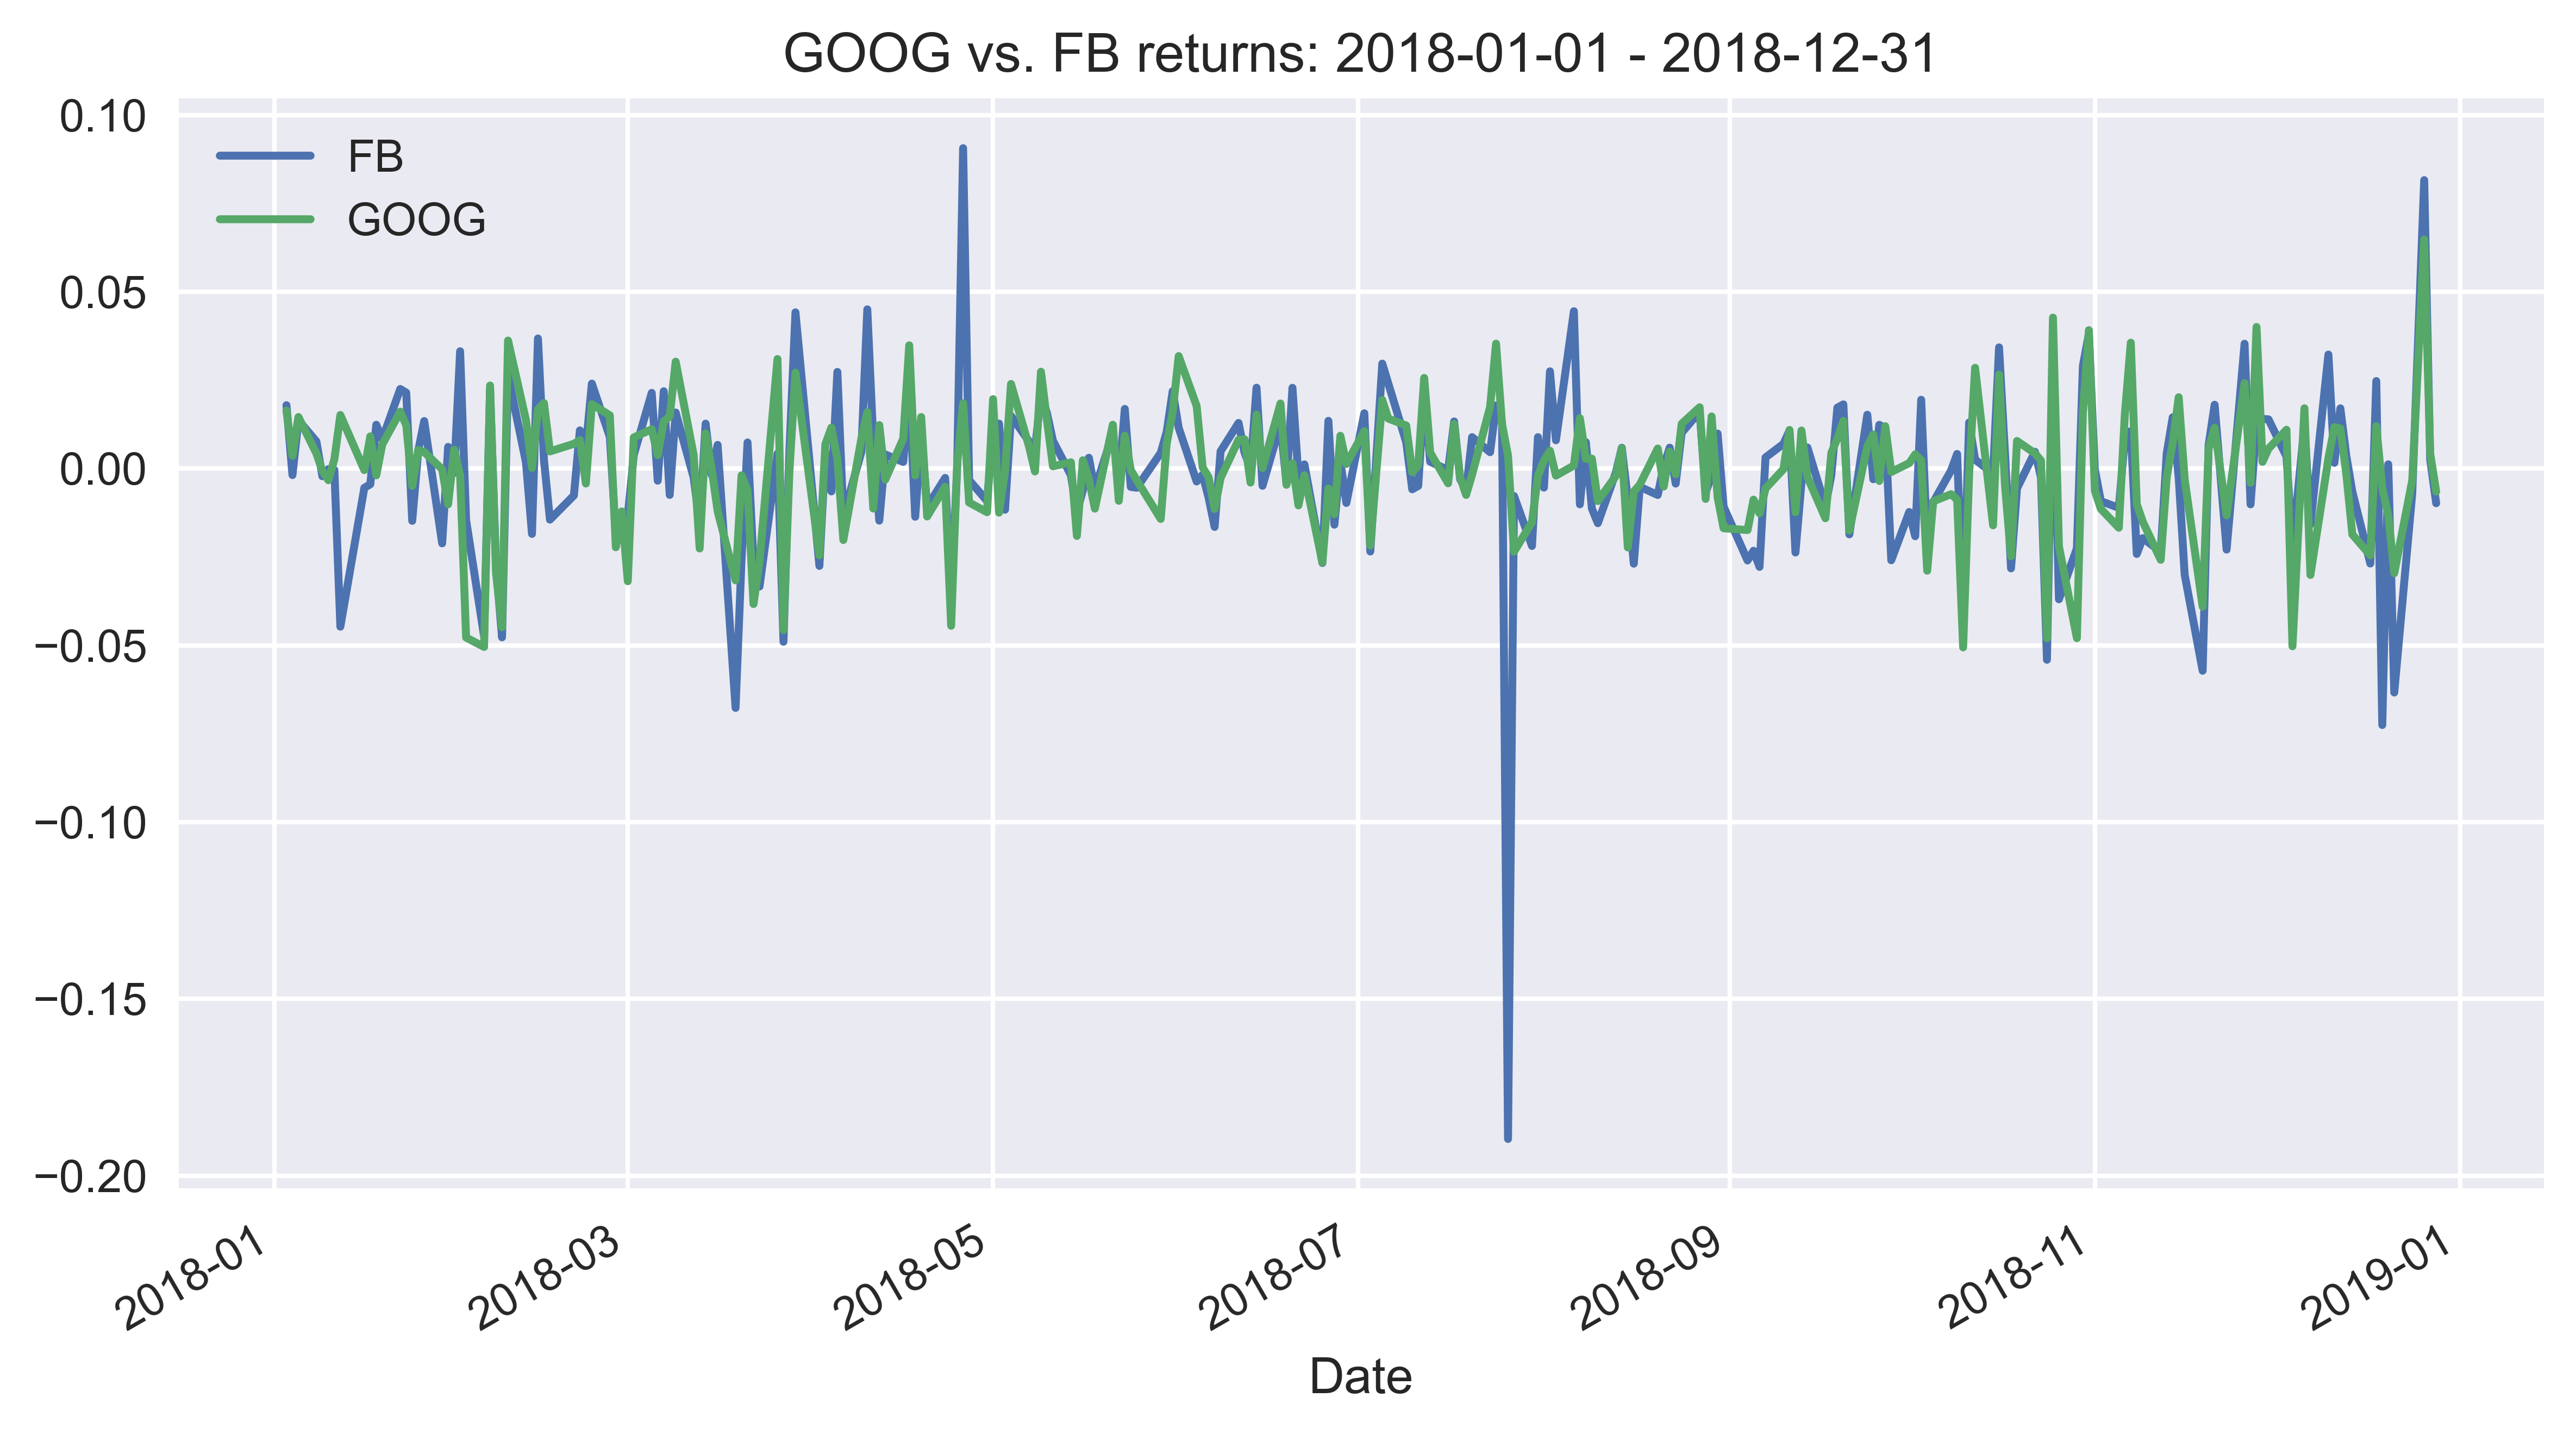

Correlation between returns: 0.62


In [43]:
adj_close = df['Adj Close']
returns = adj_close.pct_change().dropna()
plot_title = f'{" vs. ".join(RISKY_ASSETS)} returns: {START_DATE} - {END_DATE}'
returns.plot(title=plot_title)

plt.tight_layout()
plt.show()

print(f'Correlation between returns: {returns.corr().values[0,1]:.2f}')

5. Calculate the covariance matrix:

In [44]:
cov_mat = returns.cov()
cov_mat

,FB,GOOG
FB,0.000575,0.000265
GOOG,0.000265,0.000315


6. Perform the Cholesky decomposition of the covariance matrix:

In [45]:
chol_mat = np.linalg.cholesky(cov_mat)
chol_mat

array([[0.02397822, 0.        ],
       [0.01105641, 0.01389752]])

7. Draw correlated random numbers from Standard Normal distribution:

In [46]:
rv = np.random.normal(size=(N_SIMS, len(RISKY_ASSETS)))
correlated_rv = np.transpose(np.matmul(chol_mat, np.transpose(rv)))

8. Define metrics used for simulations:

In [47]:
r = np.mean(returns, axis=0).values
sigma = np.std(returns, axis=0).values
S_0 = adj_close.values[-1, :]
P_0 = np.sum(SHARES * S_0)

9. Calculate the terminal price of the considered stocks:

In [48]:
S_T = S_0 * np.exp((r - 0.5 * sigma ** 2) * T + 
                  sigma * np.sqrt(T) * correlated_rv)

10. Calculate the terminal portfolio value and calculate the portfolio returns:

In [49]:
P_T = np.sum(SHARES * S_T, axis=1)
P_diff = P_T - P_0

11. Calculate VaR:

In [50]:
P_diff_sorted = np.sort(P_diff)
percentiles = [0.01, 0.1, 1.]
var = np.percentile(P_diff_sorted, percentiles)

for x, y in zip(percentiles, var):
    print(f'1-day VaR with {100-x}% confidence: {-y:.2f}$')

1-day VaR with 99.99% confidence: 8.24$
1-day VaR with 99.9% confidence: 7.14$
1-day VaR with 99.0% confidence: 5.78$


12. Present the results on a graph:

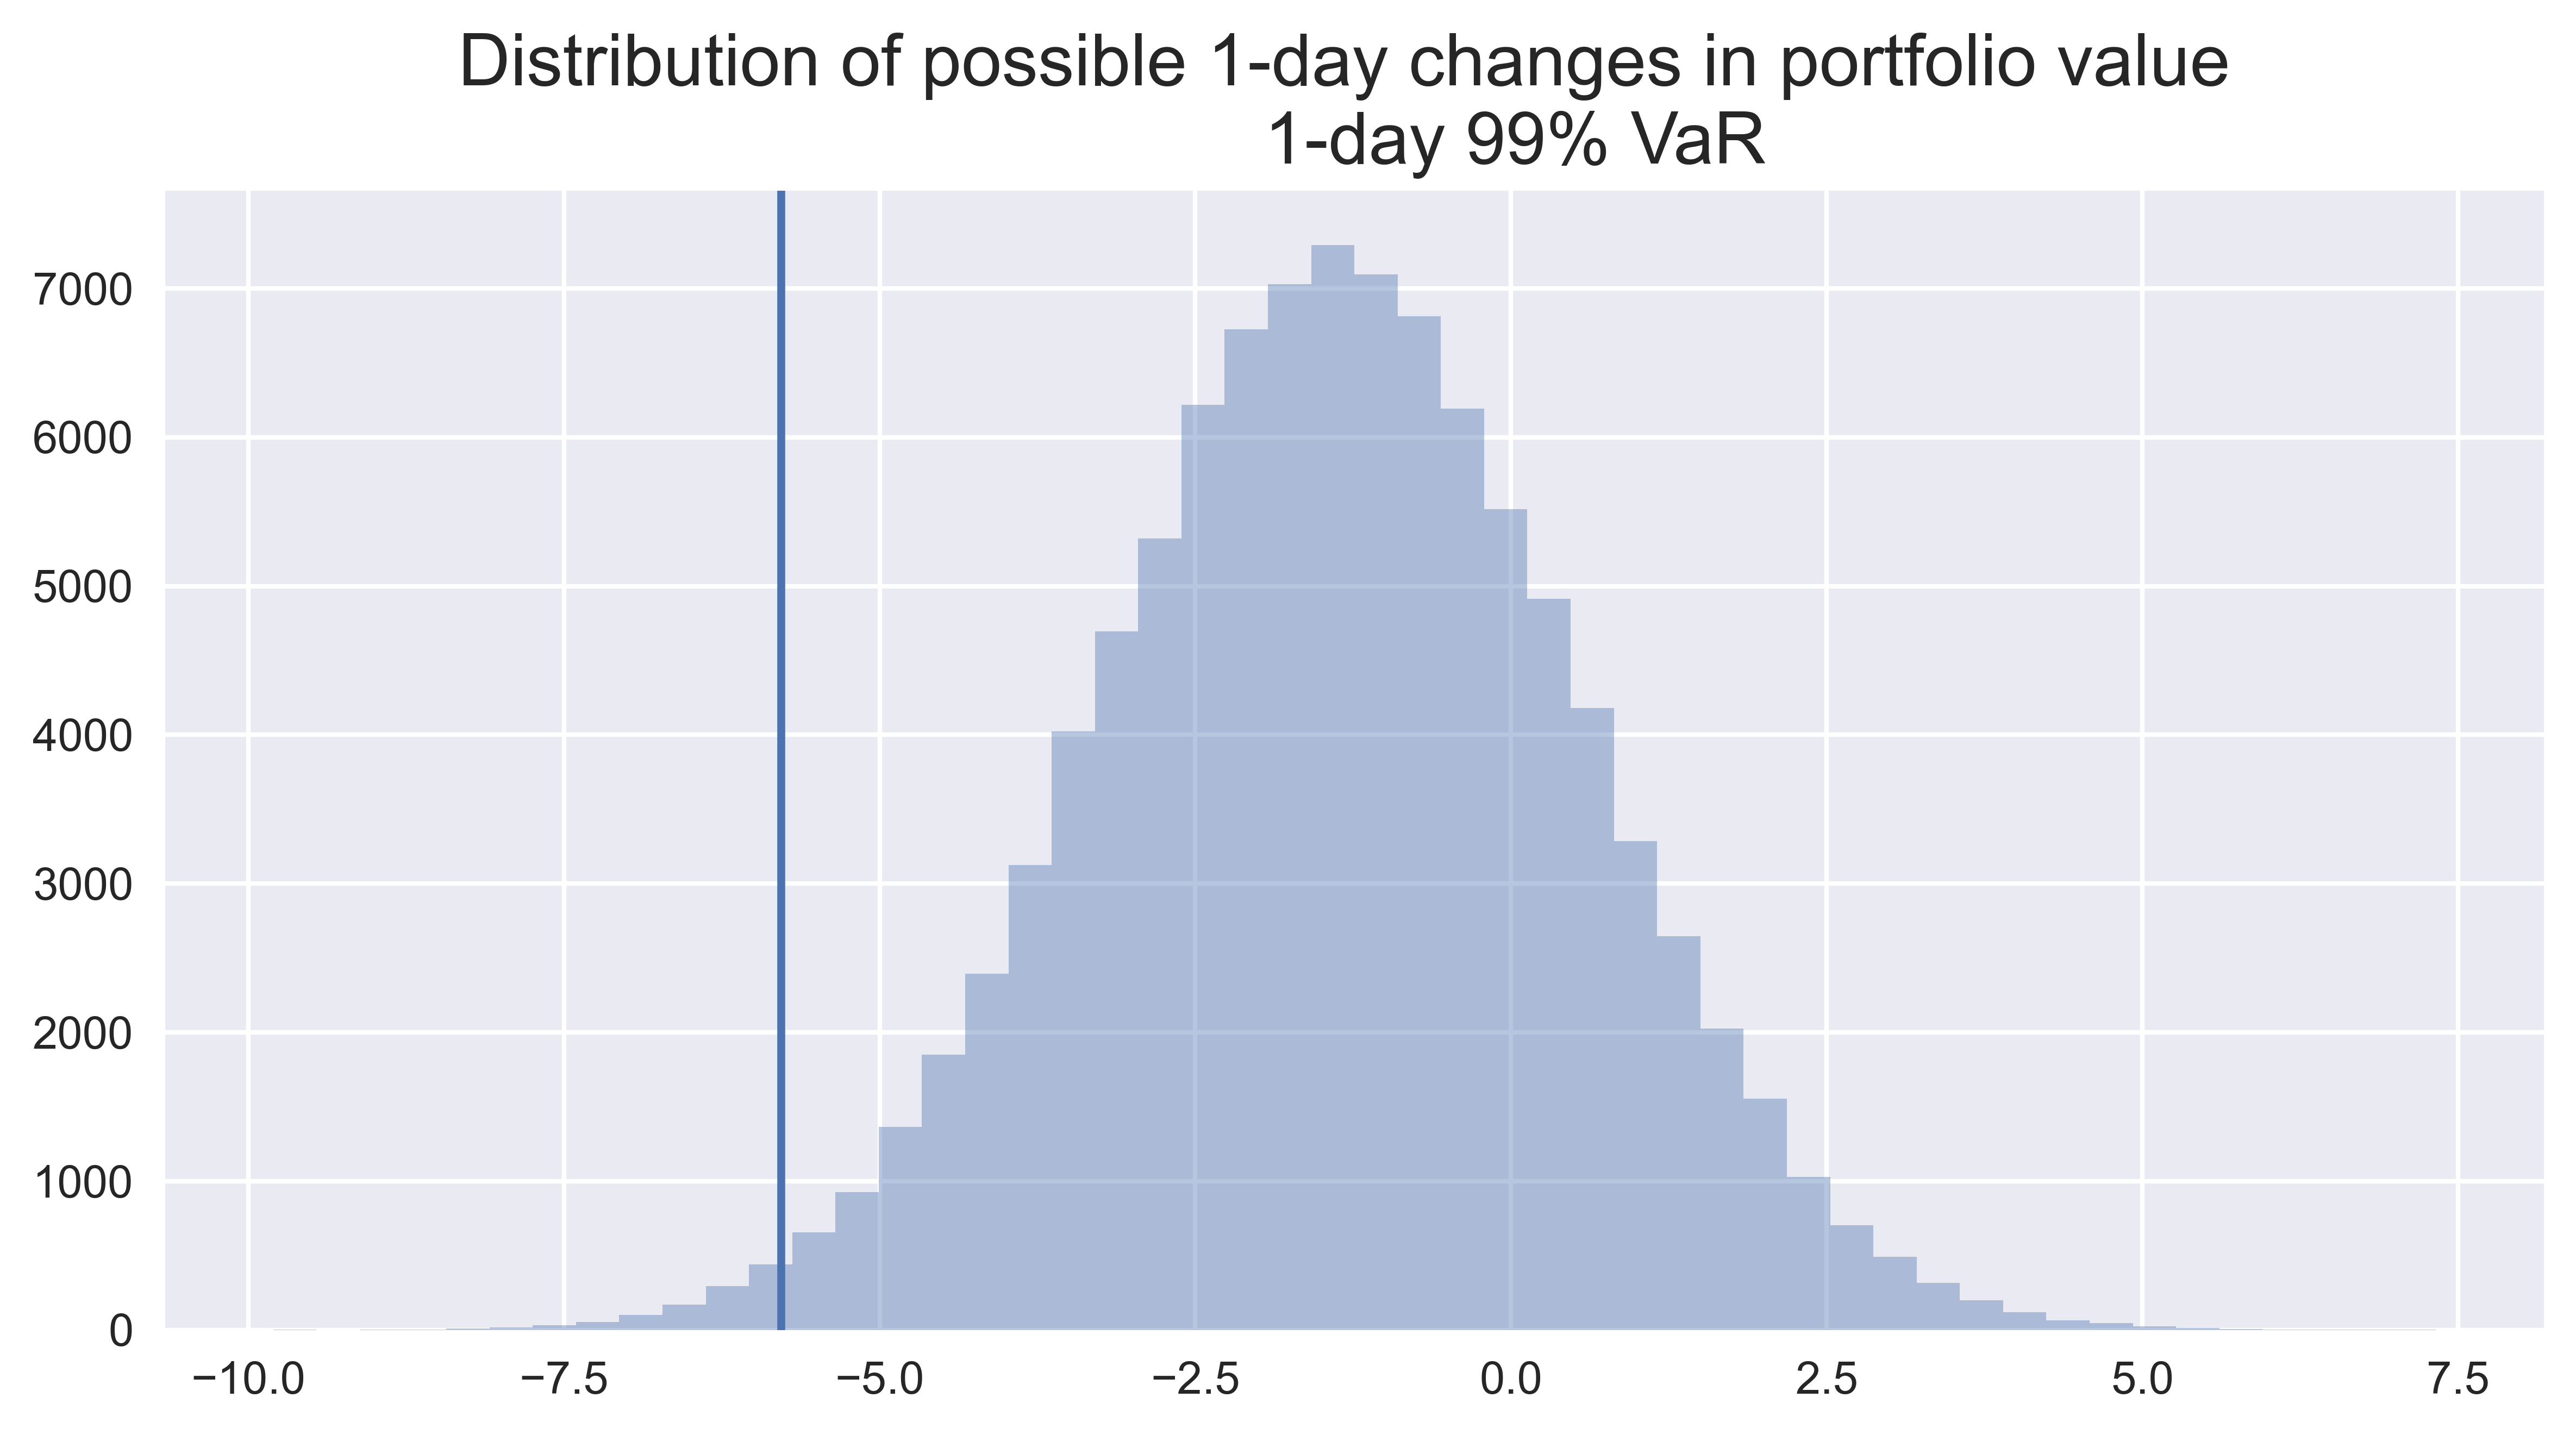

In [51]:
ax = sns.distplot(P_diff, kde=False)
ax.set_title('''Distribution of possible 1-day changes in portfolio value 
                1-day 99% VaR''''', fontsize=16)
ax.axvline(var[2], 0, 10000)

plt.tight_layout()
plt.show()